In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import train_test_split


In [5]:
train_df = pd.read_csv("Datast/train.csv")
test_df = pd.read_csv("Datast/test.csv")
building_df = pd.read_csv("Datast/building_metadata.csv")
weather_train_df = pd.read_csv("Datast/weather_train.csv")
weather_test_df = pd.read_csv("Datast/weather_test.csv")

In [6]:
print("train_df_shape ",train_df.shape,'\n',train_df.isna().sum())
print("building_df_shape",building_df.shape,'\n',building_df.isna().sum())
print("weather_train_df_shape",weather_train_df.shape,'\n',weather_train_df.isna().sum())

train_df_shape  (20216100, 4) 
 building_id      0
meter            0
timestamp        0
meter_reading    0
dtype: int64
building_df_shape (1449, 6) 
 site_id           0
building_id       0
primary_use       0
square_feet       0
year_built      774
floor_count    1094
dtype: int64
weather_train_df_shape (139773, 9) 
 site_id                   0
timestamp                 0
air_temperature          55
cloud_coverage        69173
dew_temperature         113
precip_depth_1_hr     50289
sea_level_pressure    10618
wind_direction         6268
wind_speed              304
dtype: int64


In [7]:
train_merged = train_df.merge(building_df, on="building_id", how="inner")
main_merged = train_merged.merge(weather_train_df, on=["site_id", "timestamp"], how="inner")
main_merged.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'primary_use', 'square_feet', 'year_built', 'floor_count',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed'],
      dtype='object')

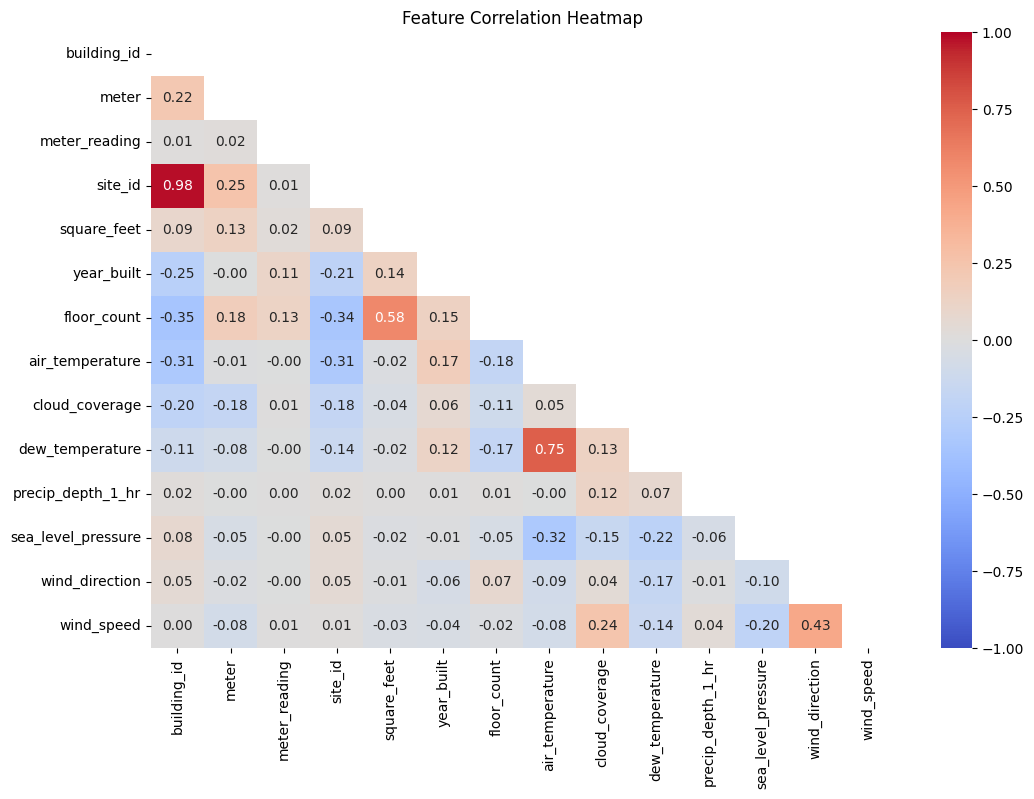

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = main_merged.select_dtypes(include=['float64', 'int64']).columns
corr_df = main_merged[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=np.triu(np.ones_like(corr_df))  # Hide upper triangle for clarity
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
cp_main=main_merged.copy()
cp_main.loc[(cp_main["site_id"] == 0) & (cp_main["meter"] == 0), "meter_reading"] *= 0.293071

In [10]:
cp_main['age']=2019-cp_main['year_built']
cp_main["meter_reading"] = np.log1p(cp_main["meter_reading"])
cp_main['square_feet'] = np.log1p(cp_main['square_feet'])
# cp_main.drop(columns=['floor_count','year_built'],inplace=True)

In [51]:
correlation = cp_main[['meter_reading', 'cloud_coverage']].corr().iloc[0, 1]
print(f"Correlation (Pearson's r): {correlation:.3f}")

Correlation (Pearson's r): -0.042


In [52]:
missing_percentage = cp_main.isnull().sum() / len(cp_main) * 100
print(missing_percentage.sort_values(ascending=False))
# cp_main.hist(bins=50,figsize=(20,18))

age                   60.188531
cloud_coverage        43.401776
precip_depth_1_hr     18.178475
wind_direction         6.750371
sea_level_pressure     5.670259
wind_speed             0.264245
dew_temperature        0.047924
air_temperature        0.030623
square_feet            0.000000
site_id                0.000000
primary_use            0.000000
timestamp              0.000000
meter                  0.000000
building_id            0.000000
meter_reading          0.000000
dtype: float64


In [56]:
cp_main['primary_use'] = cp_main['primary_use'].astype('category')
cp_main['meter'] = cp_main['meter'].astype('category')

In [57]:
cp_main["timestamp"] = pd.to_datetime(cp_main["timestamp"])
cp_main["hour"] = cp_main["timestamp"].dt.hour
cp_main["day"] = cp_main["timestamp"].dt.day
cp_main["month"] = cp_main["timestamp"].dt.month
cp_main["weekend"] = (cp_main["timestamp"].dt.weekday >= 5).astype(int)


In [21]:
xd=pd.DataFrame()
xd['mt']=cp_main['meter_reading'].copy()

In [ ]:



_0readings= list(xd[xd['mt']==0.0].index)
xd.drop(drop_0readings, axis=0, inplace=True)

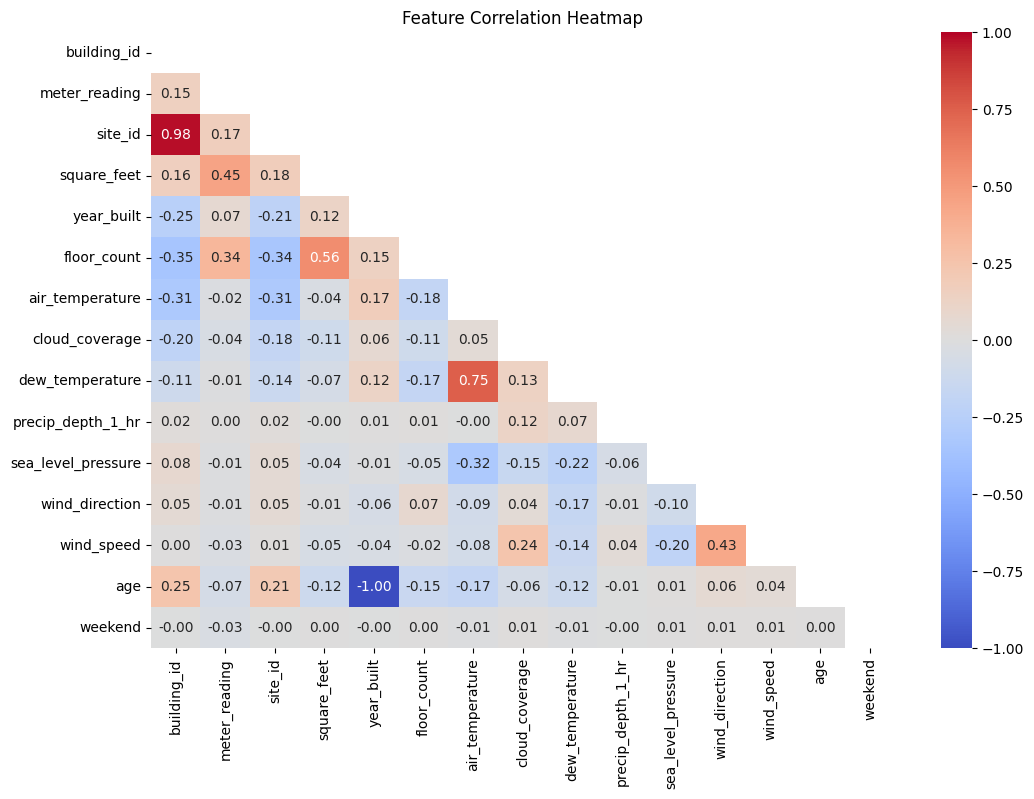

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = cp_main.select_dtypes(include=['float64', 'int64']).columns
corr_df = cp_main[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=np.triu(np.ones_like(corr_df))  # Hide upper triangle for clarity
)
plt.title("Feature Correlation Heatmap")
plt.show()

<Axes: xlabel='mt'>

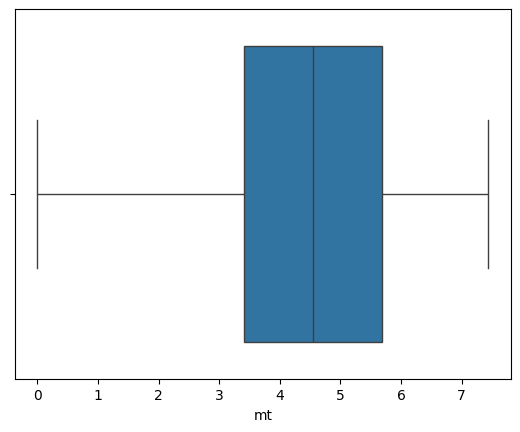

In [37]:
sns.boxplot(x=xd['mt'])
# np.percentile(xd['mt'], 99)
# xd.hist(bins=50)


In [36]:
upper_limit = np.percentile(xd['mt'], 95)
xd['mt'] = np.where(xd['mt'] > upper_limit, upper_limit, xd['mt'])
# y_capped

array([[<Axes: title={'center': 'building_id'}>,
        <Axes: title={'center': 'timestamp'}>,
        <Axes: title={'center': 'meter_reading'}>,
        <Axes: title={'center': 'site_id'}>],
       [<Axes: title={'center': 'square_feet'}>,
        <Axes: title={'center': 'air_temperature'}>,
        <Axes: title={'center': 'cloud_coverage'}>,
        <Axes: title={'center': 'dew_temperature'}>],
       [<Axes: title={'center': 'precip_depth_1_hr'}>,
        <Axes: title={'center': 'sea_level_pressure'}>,
        <Axes: title={'center': 'wind_direction'}>,
        <Axes: title={'center': 'wind_speed'}>],
       [<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'day'}>,
        <Axes: title={'center': 'month'}>],
       [<Axes: title={'center': 'weekend'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

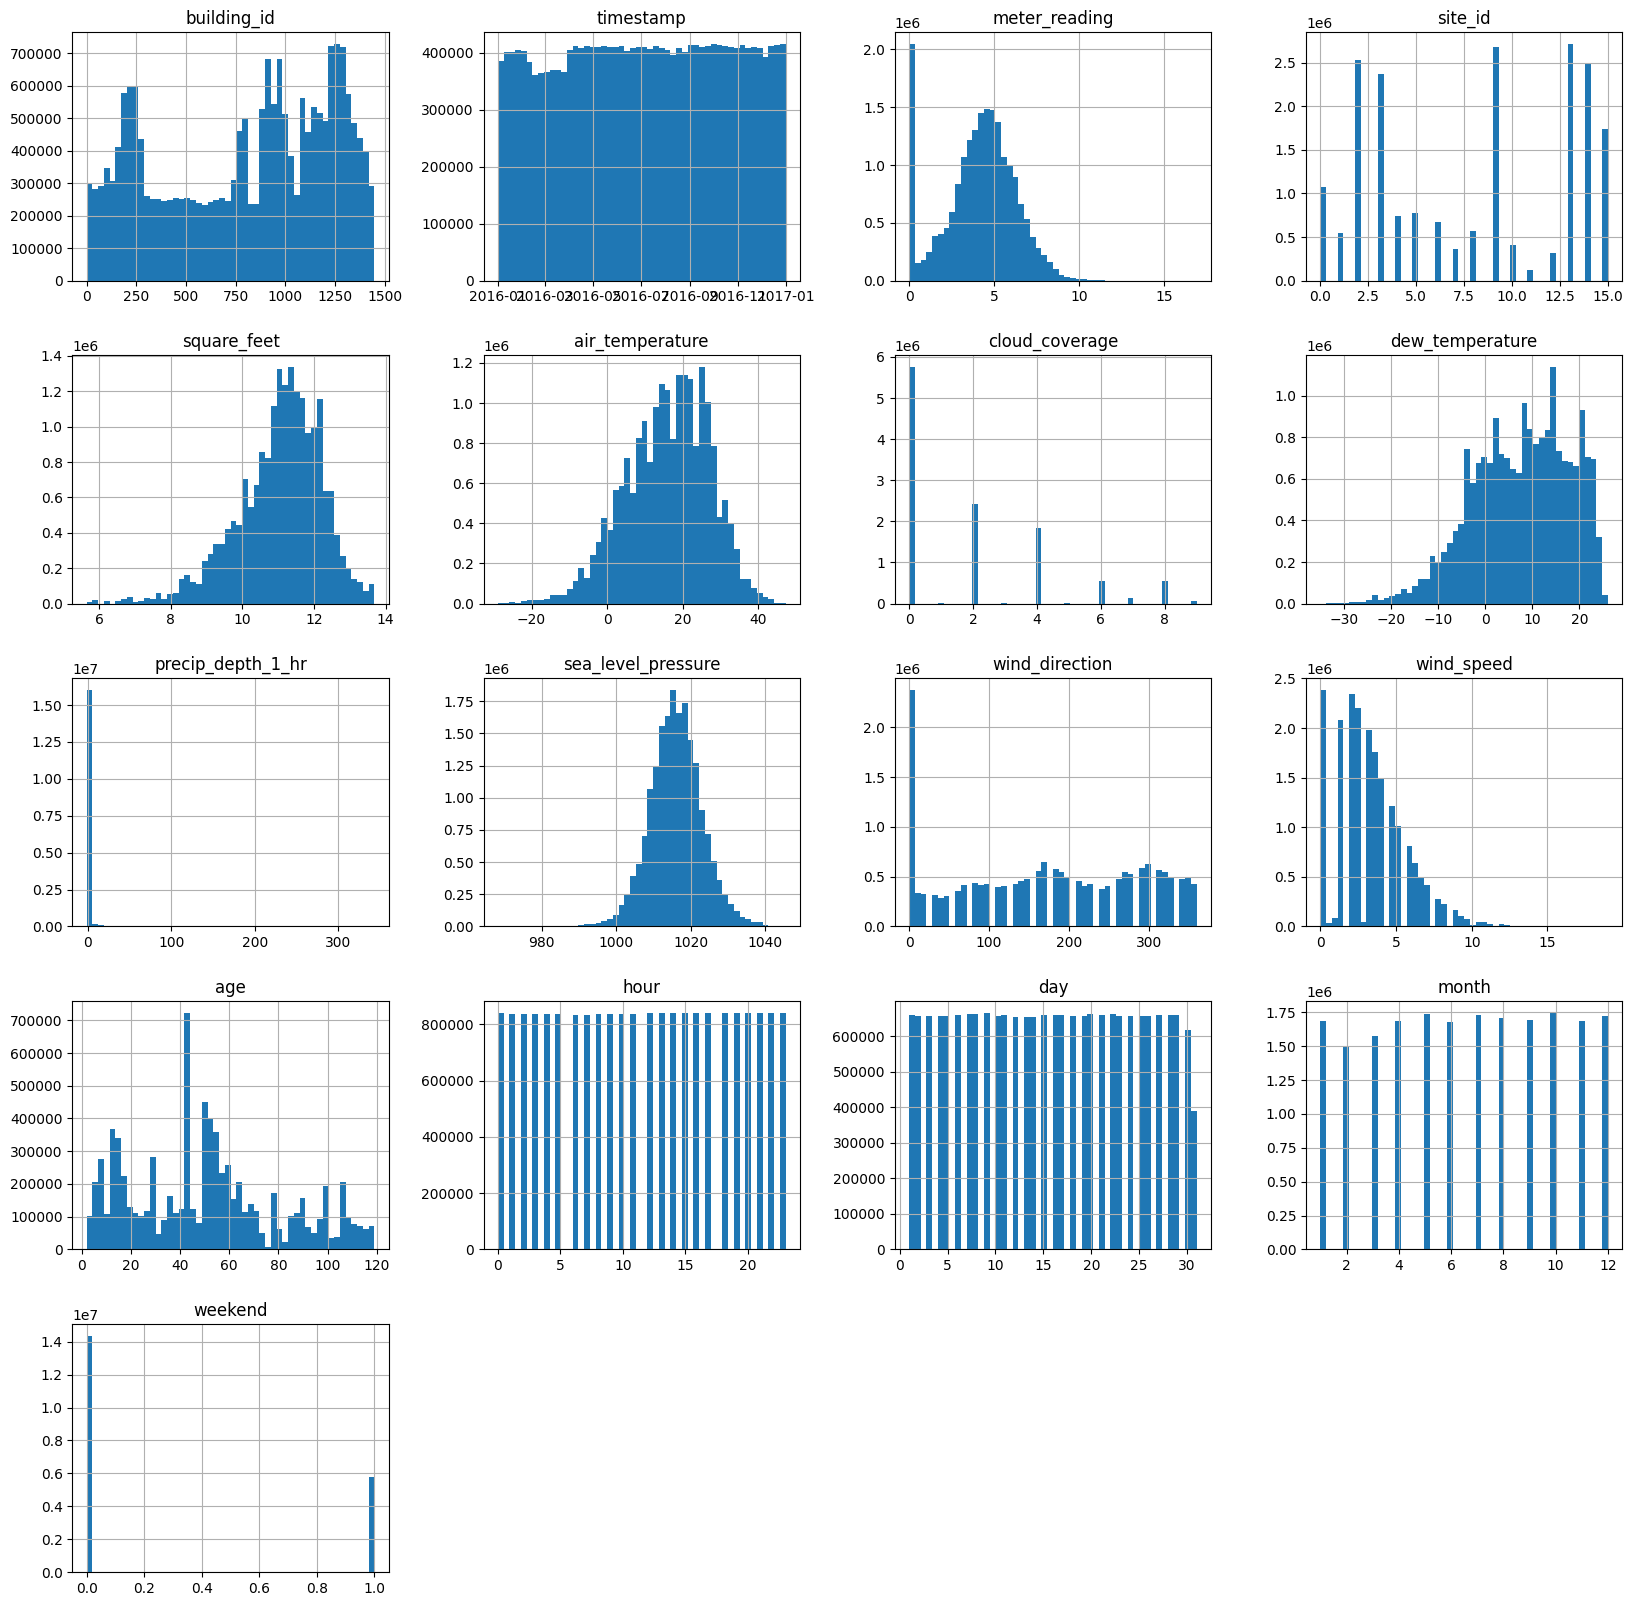

In [38]:
cp_main.hist(bins=50,figsize=(20,20))

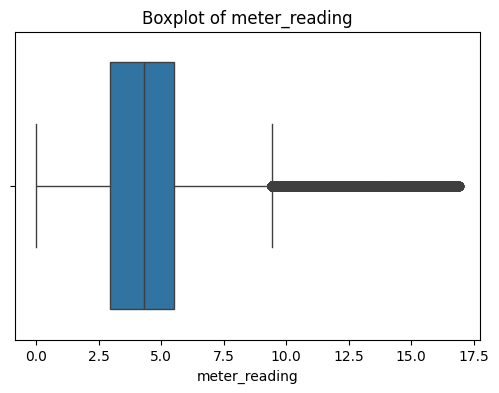

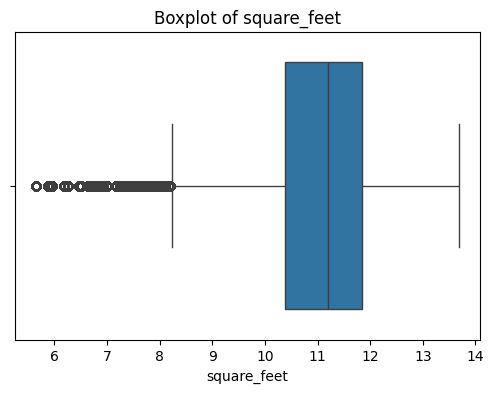

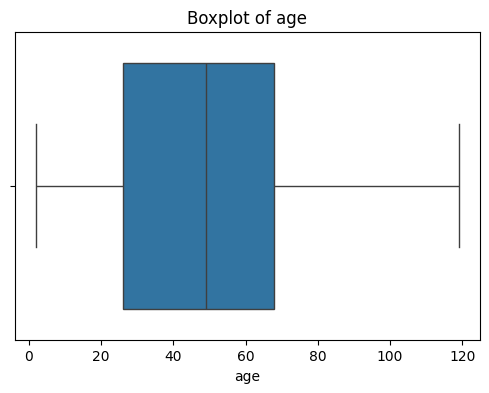

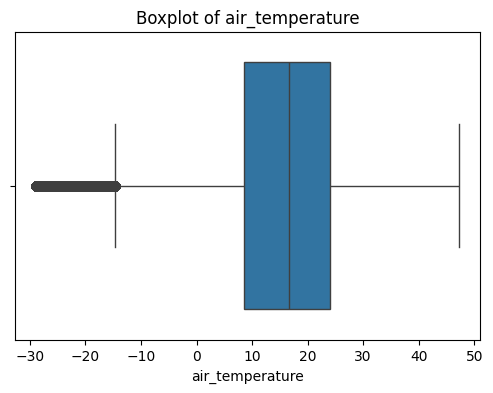

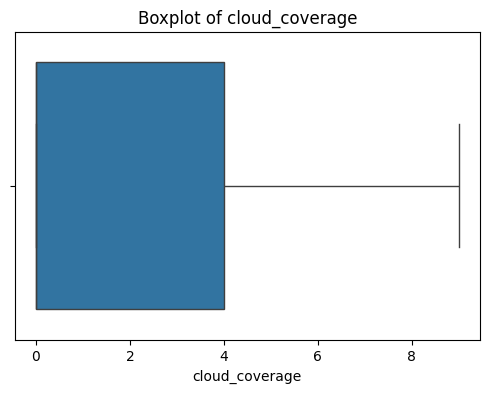

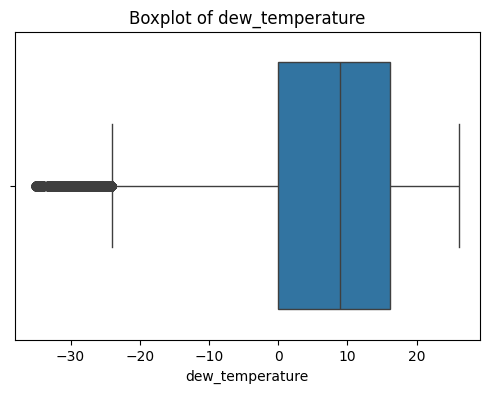

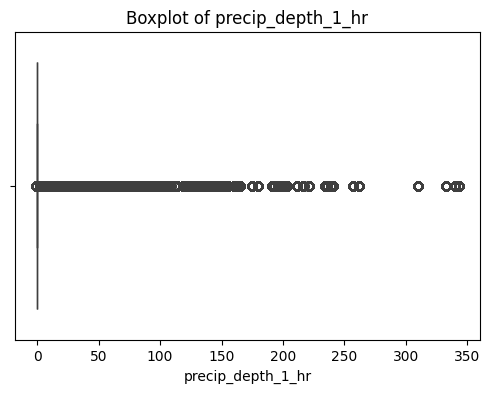

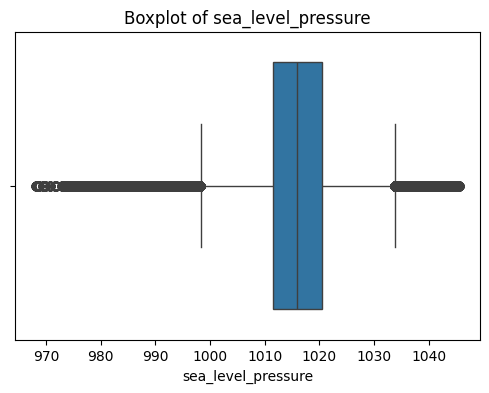

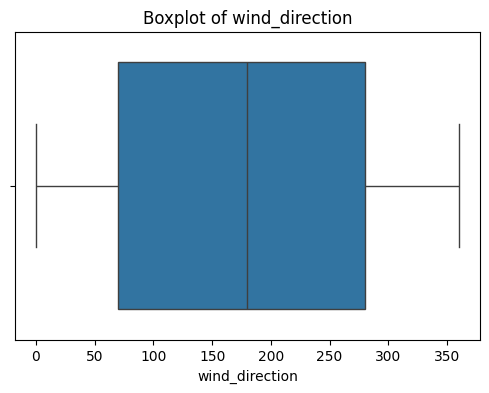

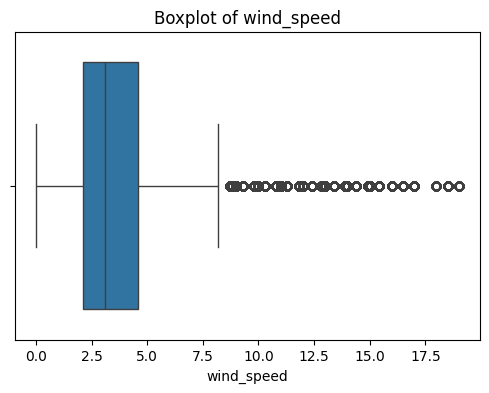

In [39]:
col=['meter_reading', 'square_feet', 'age','air_temperature', 'cloud_coverage', 'dew_temperature','precip_depth_1_hr', 'sea_level_pressure', 'wind_direction','wind_speed']

# Plot each column separately
for col in col:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=cp_main[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [40]:
cp_main["cloud_coverage"]=cp_main["cloud_coverage"].ffill()
cp_main.dropna(subset=['wind_direction'], inplace=True)
cp_main.dropna(subset=['sea_level_pressure'], inplace=True)
cp_main.dropna(subset=['wind_speed'], inplace=True)
cp_main.dropna(subset=['dew_temperature'], inplace=True)
cp_main.dropna(subset=['air_temperature'], inplace=True)
cp_main.dropna(subset=['precip_depth_1_hr'], inplace=True)

In [41]:
missing_percentage = cp_main.isnull().sum() / len(cp_main) * 100
print(missing_percentage.sort_values(ascending=False))

age                   67.625376
meter                  0.000000
building_id            0.000000
timestamp              0.000000
meter_reading          0.000000
primary_use            0.000000
site_id                0.000000
air_temperature        0.000000
cloud_coverage         0.000000
dew_temperature        0.000000
square_feet            0.000000
precip_depth_1_hr      0.000000
sea_level_pressure     0.000000
wind_direction         0.000000
wind_speed             0.000000
hour                   0.000000
day                    0.000000
month                  0.000000
weekend                0.000000
dtype: float64


In [ ]:
# cp_main['age'].hist(bins=50)
# cp_main['age'].median()

In [42]:
from meteocalc import feels_like, Temp, dew_point, wind_chill, heat_index

In [43]:
temp_format = cp_main.air_temperature.apply(lambda x : Temp(x, 'c'))

In [44]:
import math
def compute_humidity(row):
    CONSTANTS = dict(
        positive=dict(b=17.368, c=238.88),
        negative=dict(b=17.966, c=247.15),
    )
    T = row["air_temperature"]
    const = CONSTANTS['positive'] if T > 0 else CONSTANTS['negative']
    dp = row["dew_temperature"]
    pa = math.exp(dp * const['b'] / (const['c'] + dp))
    rel_humidity = pa * 100. * 1 / math.exp(const['b'] * T / (const['c'] + T))
    return(rel_humidity)

In [45]:
cp_main["relative_humidity"] = cp_main.apply(lambda x: compute_humidity(x), axis = 1)

In [47]:
dew_point(temperature = cp_main["air_temperature"][1], humidity = cp_main["relative_humidity"][1]).f

KeyError: 1

In [ ]:
cp_main["air_temp_f"] = cp_main["air_temperature"] * 9 / 5. + 32

In [ ]:
def feels_like_custom(row):
    temperature = row["air_temp_f"]
    wind_speed = row["wind_speed"]
    humidity = row["relative_humidity"]
    fl = feels_like(temperature, wind_speed, humidity)
    out = fl.c
    return(out)

In [ ]:
cp_main["feels_like_temp"] = cp_main.apply(lambda x : feels_like_custom(x), axis = 1)

In [ ]:
cp_main['precip_depth_1_hr'].describe()

In [ ]:
cp_main['precip_depth_1_hr'].value_counts()

In [ ]:
cp_main['precip_depth_1_hr'] = cp_main['precip_depth_1_hr'].replace(-1, np.nan)

In [ ]:
xd=pd.DataFrame()
xd['prec']=cp_main["precip_depth_1_hr"].rolling(12, min_periods=1).sum()

In [ ]:
xd['prec'].describe()

In [ ]:
cp_main['precip_depth_1_hr'].isna().sum()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
# numeric_cols = cp_main.select_dtypes(include=["number"]).columns
col=['meter_reading', 'square_feet','air_temperature', 'cloud_coverage', 'dew_temperature','precip_depth_1_hr', 'sea_level_pressure', 'wind_direction','wind_speed','feels_like_temp']

# Plot each column separately
for col in col:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=cp_main[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [ ]:
Q1 = cp_main["meter_reading"].quantile(0.25)
Q3 = cp_main["meter_reading"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = cp_main[(cp_main["meter_reading"] < lower_bound) | (cp_main["meter_reading"] > upper_bound)]
print(f"Outliers: {len(outliers)} ({len(outliers)/len(cp_main)*100:.2f}%)")

In [ ]:
from sklearn.preprocessing import RobustScaler
# cp_main["target_scaled"] = RobustScaler().fit_transform(cp_main[["meter_reading"]])
df_clean = cp_main[(cp_main["meter_reading"] >= lower_bound) & (cp_main["meter_reading"] <= upper_bound)]

In [ ]:
df_clean

In [ ]:
sns.boxplot(x=df_clean['meter_reading'])

In [ ]:
# cp_main['precip_depth_1_hr'] = cp_main['precip_depth_1_hr'].apply(lambda x: x if x != -1 else np.random.rand(0, 5))

In [ ]:
cp_main.hist(bins=50,figsize=(20,20))

In [ ]:
drop_0readings= list(cp_main[cp_main['meter_reading']==0.0].index)
cp_main.drop(drop_0readings, axis=0, inplace=True)

In [ ]:
# features = ["meter", "hour", "day", "month", "weekend",'sea_level_pressure']
features=['feels_like_temp','age','cloud_coverage','relative_humidity','sea_level_pressure','day','month','square_feet']
target = "meter_reading"

X = df_clean[features]
y = df_clean[target]

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 1000,
    "verbose": -1
}

# Convert to LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Train the model
# model = lgb.train(params, train_data, valid_sets=[val_data], early_stopping_rounds=50, verbose_eval=100)
model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
)


In [ ]:
from sklearn.metrics import r2_score
y_train_pred = model.predict(X_train)

# Calculate R² Score
r2 = r2_score(y_train, y_train_pred)
print("Training R² Score:", r2)
y_test_pred = model.predict(X_val)

# Calculate R² Score
r2_test = r2_score(y_val, y_test_pred)
print("Test R² Score:", r2_test)

In [11]:
cp_main.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,age
0,0,0,2016-01-01 00:00:00,0.0,0,Education,8.913685,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,11.0
1,1,0,2016-01-01 00:00:00,0.0,0,Education,7.908755,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,15.0
2,2,0,2016-01-01 00:00:00,0.0,0,Education,8.589886,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,28.0
3,3,0,2016-01-01 00:00:00,0.0,0,Education,10.072639,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,17.0
4,4,0,2016-01-01 00:00:00,0.0,0,Education,11.666573,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,44.0


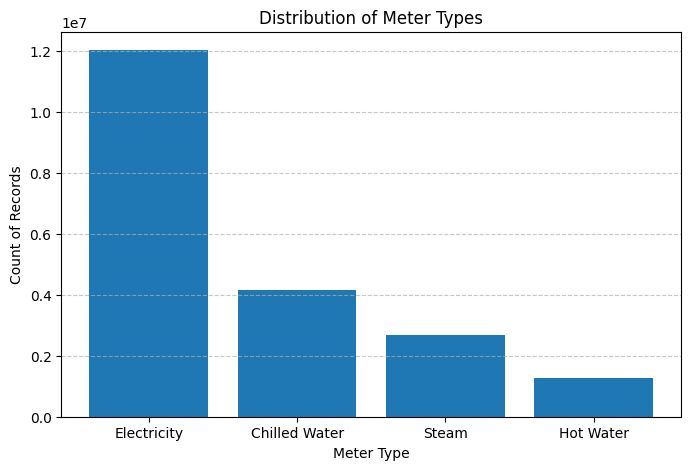

In [16]:
import matplotlib.pyplot as plt

# Define meter type mapping from Ashrae competition
meter_types = {0: "Electricity", 1: "Chilled Water", 2: "Steam", 3: "Hot Water"}

# Count occurrences of each meter type
meter_counts = cp_main['meter'].value_counts().sort_index()

# Map numeric meter types to actual names
meter_labels = [meter_types[m] for m in meter_counts.index]

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(meter_labels, meter_counts)

# Labeling
plt.xlabel("Meter Type")
plt.ylabel("Count of Records")
plt.title("Distribution of Meter Types")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


C:\Users\zyzai\AppData\Local\Temp\ipykernel_25224\3035294181.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  meter_efficiency = cp_main.groupby("meter").apply(lambda x: (x["meter_reading"] / x["square_feet"]).mean())


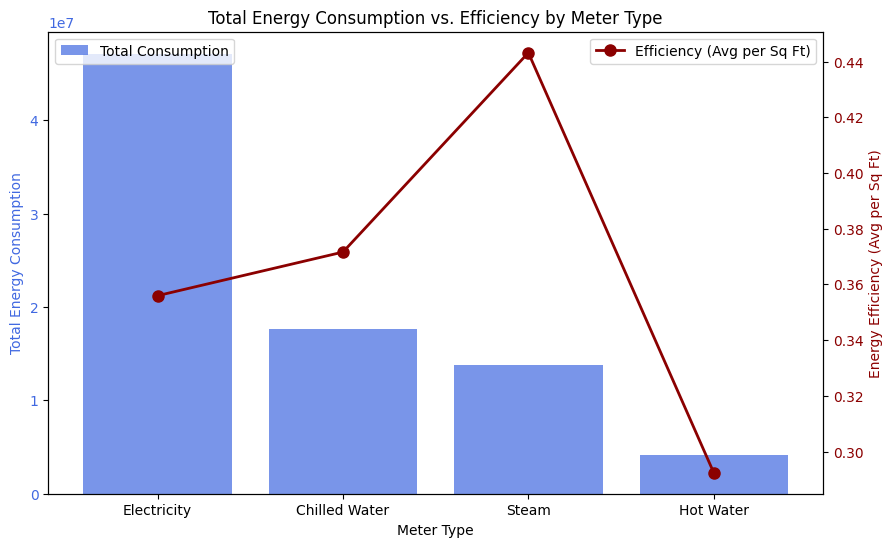

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define meter type mapping from ASHRAE competition
meter_types = {0: "Electricity", 1: "Chilled Water", 2: "Steam", 3: "Hot Water"}

# Calculate total energy consumption per meter type
meter_consumption = cp_main.groupby("meter")["meter_reading"].sum()

# Calculate efficiency (energy usage per square foot)
meter_efficiency = cp_main.groupby("meter").apply(lambda x: (x["meter_reading"] / x["square_feet"]).mean())

# Convert meter indices to names
meter_consumption.index = [meter_types[m] for m in meter_consumption.index]
meter_efficiency.index = [meter_types[m] for m in meter_efficiency.index]

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot total energy consumption (Left Y-Axis)
ax1.bar(meter_consumption.index, meter_consumption.values, color='royalblue', alpha=0.7, label="Total Consumption")
ax1.set_ylabel("Total Energy Consumption", color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')

# Create second y-axis
ax2 = ax1.twinx()
ax2.plot(meter_efficiency.index, meter_efficiency.values, color='darkred', marker='o', markersize=8, label="Efficiency (Avg per Sq Ft)", linewidth=2)
ax2.set_ylabel("Energy Efficiency (Avg per Sq Ft)", color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

# Titles and labels
plt.title("Total Energy Consumption vs. Efficiency by Meter Type")
ax1.set_xlabel("Meter Type")

# Add legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.show()


In [18]:
cp_main

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,age
0,0,0,2016-01-01 00:00:00,0.000000,0,Education,8.913685,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,11.0
1,1,0,2016-01-01 00:00:00,0.000000,0,Education,7.908755,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,15.0
2,2,0,2016-01-01 00:00:00,0.000000,0,Education,8.589886,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,28.0
3,3,0,2016-01-01 00:00:00,0.000000,0,Education,10.072639,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,17.0
4,4,0,2016-01-01 00:00:00,0.000000,0,Education,11.666573,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20125600,1444,0,2016-12-31 23:00:00,2.277267,15,Entertainment/public assembly,9.884305,1914.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,105.0
20125601,1445,0,2016-12-31 23:00:00,1.762159,15,Education,8.366138,NaN,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,NaN
20125602,1446,0,2016-12-31 23:00:00,0.000000,15,Entertainment/public assembly,9.329545,1997.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,22.0
20125603,1447,0,2016-12-31 23:00:00,5.078761,15,Lodging/residential,10.301458,2001.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,18.0
